In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "908803302"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"

In [21]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1.png"):
    compression_order = ["Original", "8-bit", "4-bit"]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Compression", y=score_col, hue="Model", marker="o")
    plt.title(f"{miaName}({score_col}) Score Across Compression Levels for Different Pythia Models")
    plt.ylabel(f"{score_col} Score")
    plt.xlabel("Compression Level")
    plt.grid(True)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}", dpi=300, bbox_inches="tight")
    plt.show()

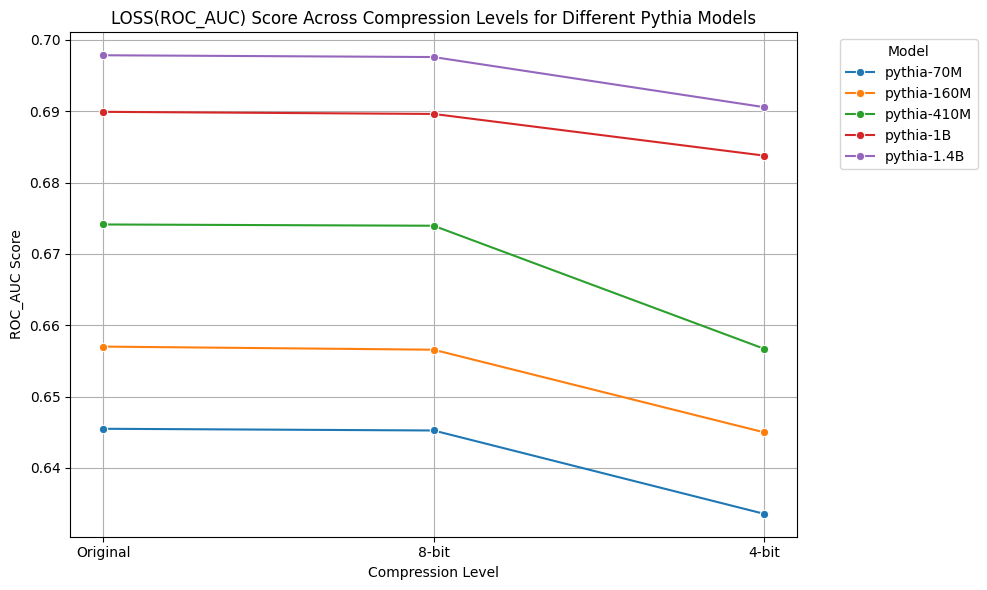

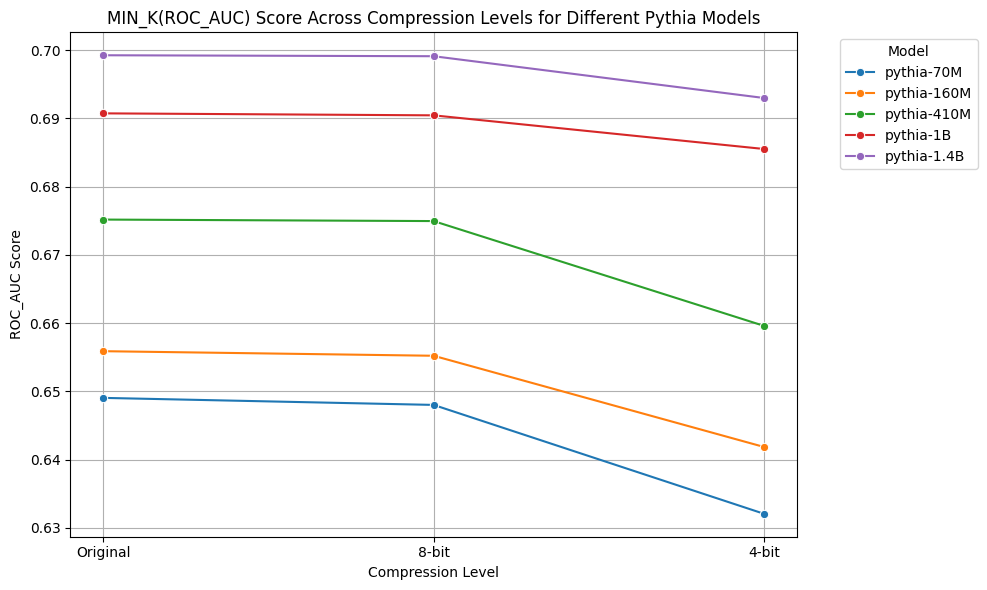

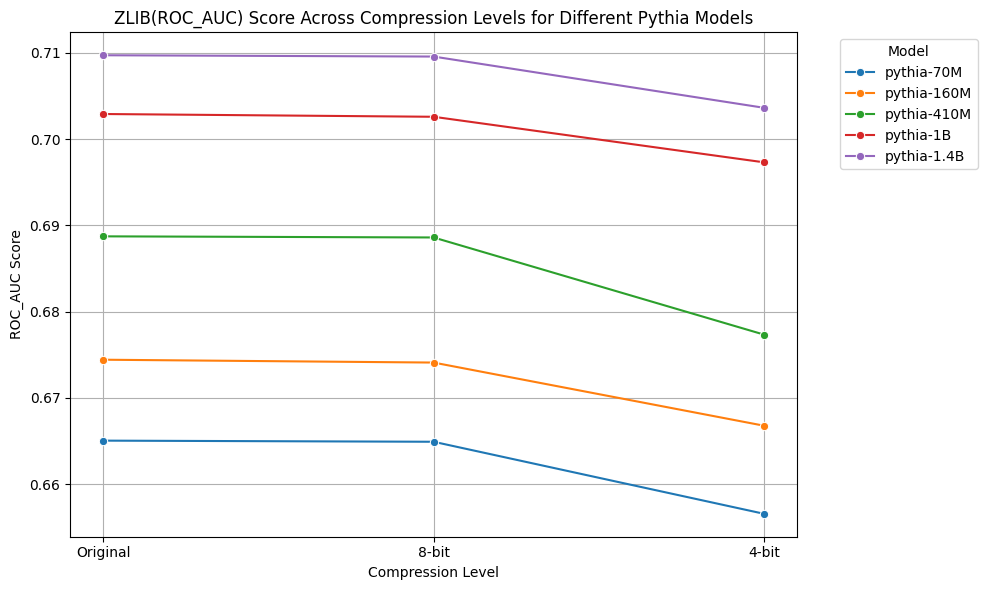

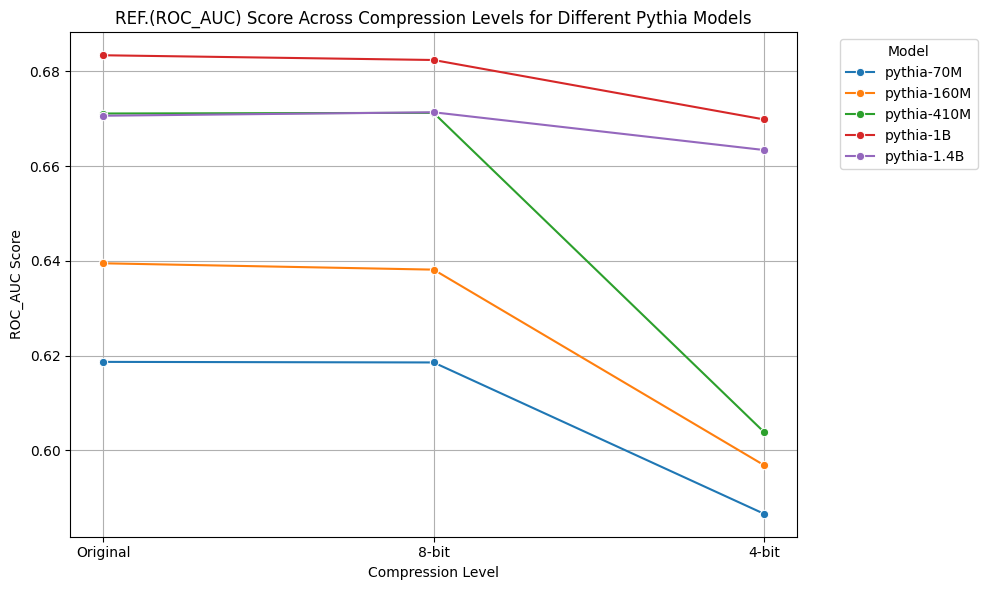

In [27]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"])
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-2.1.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"])
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-2.2.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"])
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-2.3.png")
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"])

df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-2.4.png")

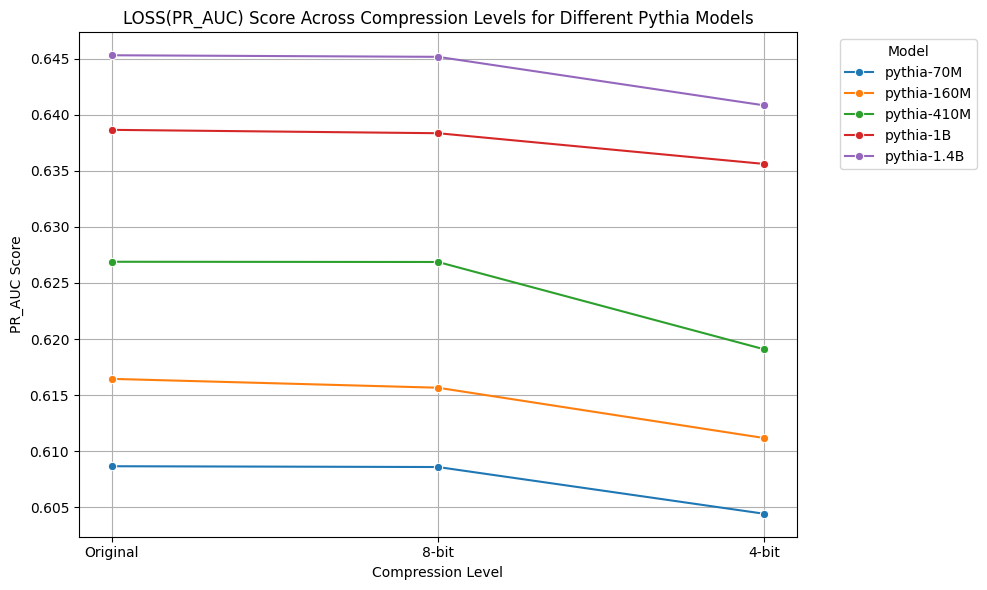

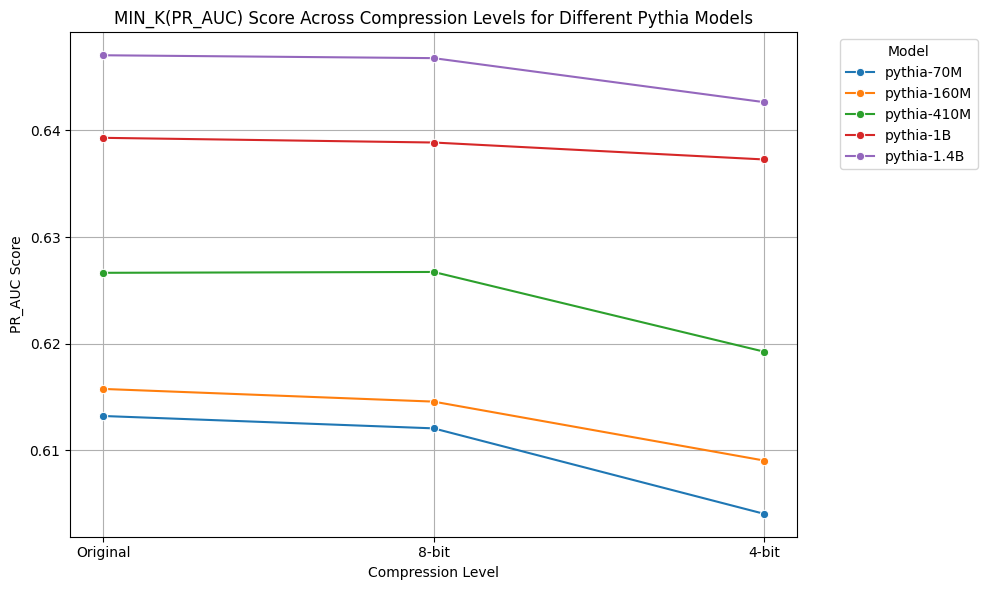

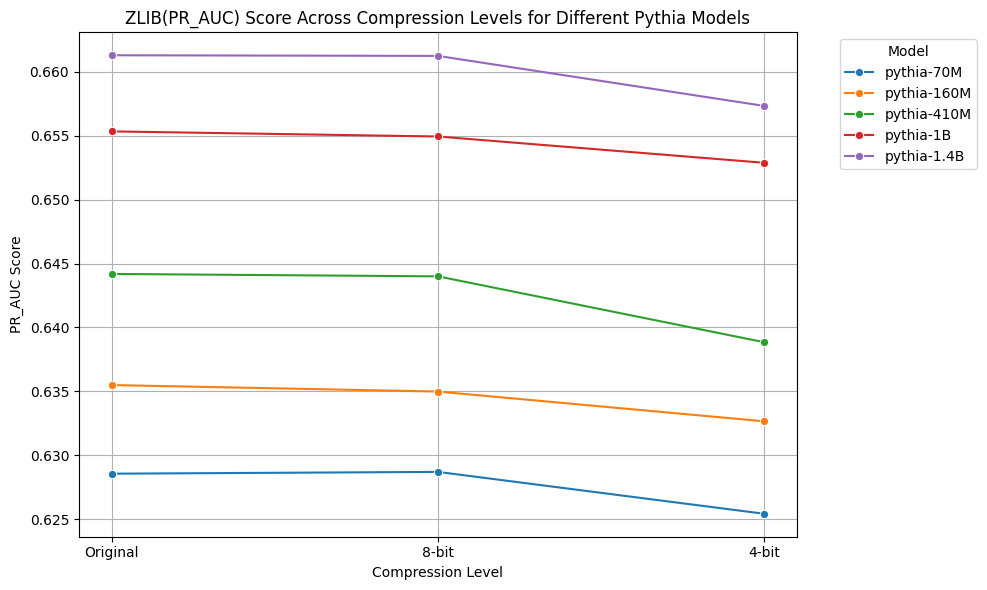

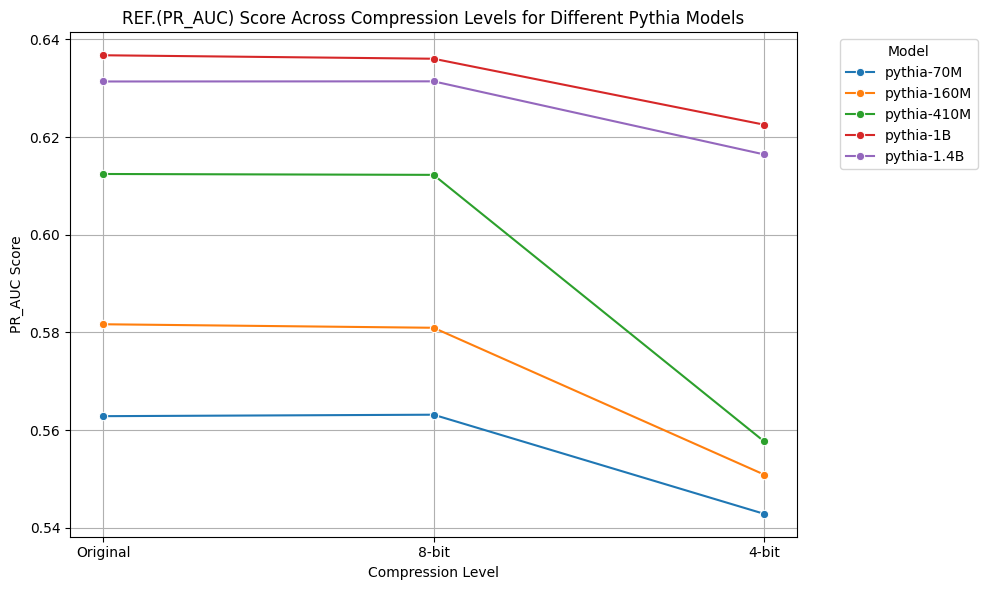

In [28]:
metric = "PR_AUC"

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", metric])
graph_roc_auc(df, score_col=metric, miaName="LOSS", fileName="RQ-2.5.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.1"])
df = df.rename(columns={"PR_AUC.1": metric})
graph_roc_auc(df, score_col=metric, miaName="MIN_K", fileName="RQ-2.6.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.2"])
df = df.rename(columns={"PR_AUC.2": metric})
graph_roc_auc(df, score_col=metric, miaName="ZLIB", fileName="RQ-2.7.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.3"])
df = df.rename(columns={"PR_AUC.3": metric})
graph_roc_auc(df, score_col=metric, miaName="REF.", fileName="RQ-2.8.png")